In [3]:
# Install the necessary libraries

!pip install pandas scikit-learn matplotlib seaborn

#Import the necessary libraries

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

Mount the Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Reading the Data

In [8]:
df= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Housing[1].csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Data Exploration and Cleaning

In [19]:
# Check for missing values
df.info()

#Check statistical summary of the dataset
df.describe()

# Identify columns with 0 non-null values
empty_cols = [col for col in df.columns if df[col].isnull().all()]

# Drop the empty columns
df = df.drop(columns=empty_cols)

# Check if there are any missing values after dropping empty columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            545 non-null    int64  
 1   area                             545 non-null    int64  
 2   bedrooms                         545 non-null    int64  
 3   bathrooms                        545 non-null    int64  
 4   stories                          545 non-null    int64  
 5   mainroad                         0 non-null      float64
 6   guestroom                        0 non-null      float64
 7   basement                         0 non-null      float64
 8   hotwaterheating                  0 non-null      float64
 9   airconditioning                  0 non-null      float64
 10  parking                          545 non-null    int64  
 11  prefarea                         0 non-null      float64
 12  furnishingstatus_semi-

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
parking,0
furnishingstatus_semi-furnished,0
furnishingstatus_unfurnished,0


Feature Selection

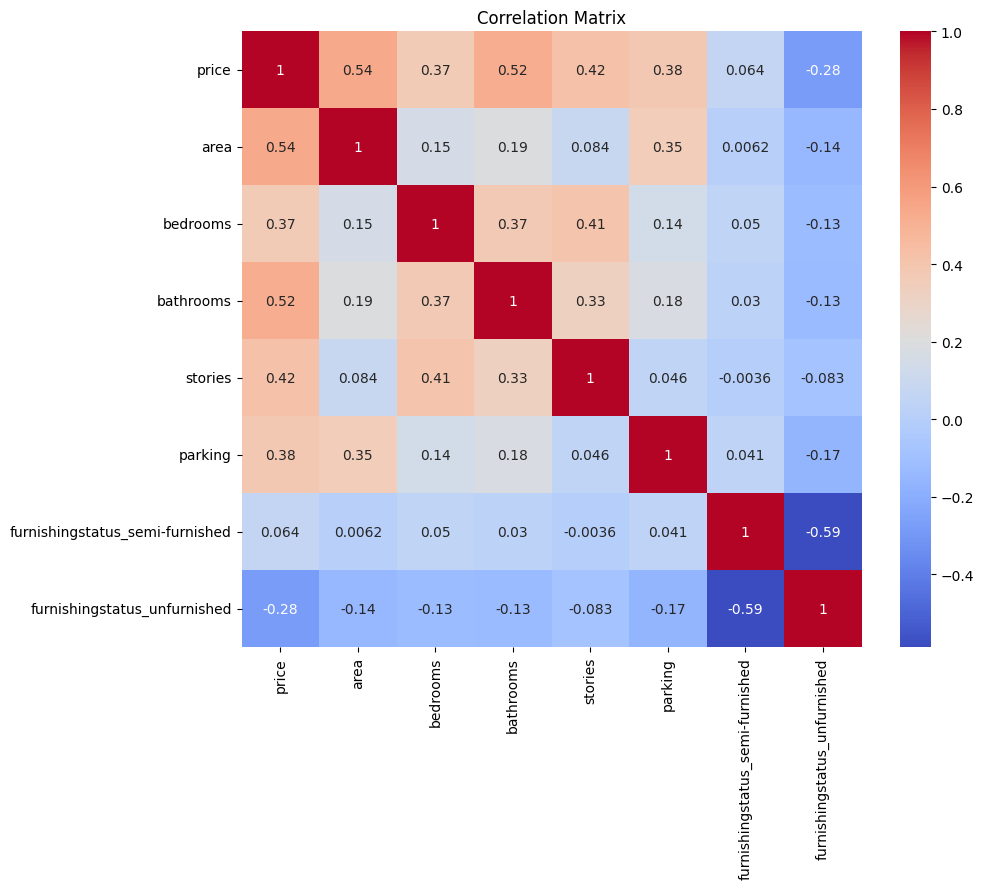

In [20]:
# Define the independent variables (features) and dependent variable (target)
X=df.drop('price', axis=1) # Features (excluding price)
y=df['price'] # Target variable

#Display correlation matrix to understand feature importance
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Splitting Data into Training and Testing Sets

In [21]:
#Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Check the shape of the datasets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(436, 7) (109, 7) (436,) (109,)


Model Training using Linear Regression

In [22]:
#Initialize the Linear Regression model
model=LinearRegression()

#Train the model
model.fit(X_train, y_train)

#Predict on the test data y_pred model.predict(X_test)
y_pred=model.predict(X_test)
#Model coefficients (weights) and intercept
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [ 3.00828635e+02  1.44537714e+05  1.15490051e+06  4.64070182e+05
  2.94519572e+05 -2.80890184e+05 -6.86630267e+05]
Model Intercept: 574070.6609556898


Model Evaluation

In [23]:
#Evaluate the model performance

mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)

Mean Squared Error (MSE): 2229169358205.0586
Root Mean Squared Error (RMSE): 1493040.306959279
R-squared (R2) Score: 0.5589794483892094


Visualization of Actual vs Predicted Values

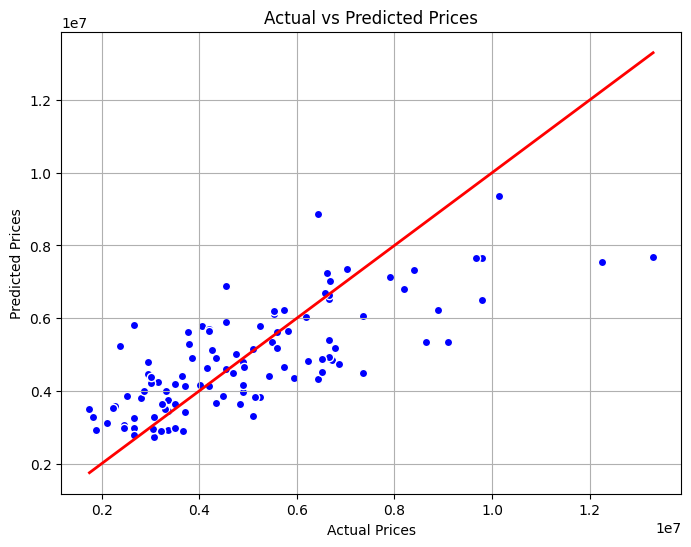

In [24]:
# Create a scatter plot to compare actual vs predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='w')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

Resdidual Plot

In [25]:
pip install statsmodels

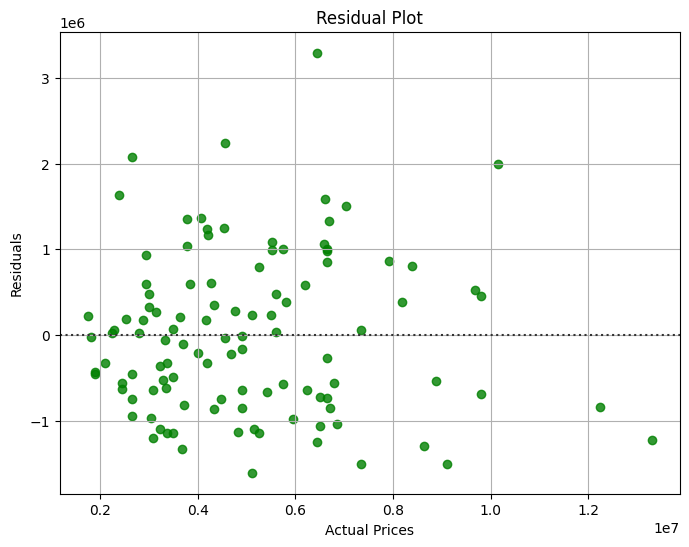

In [26]:
#Plot the residuals (errors) without Lowess
plt.figure(figsize=(8,6))
sns.residplot(x=y_test, y=y_pred, color='green', line_kws={'color': 'red', 'lw': 2})
plt.title('Residual Plot')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

# Apply scaling to features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score

#Perform 5-fold cross-validation
cross_val_scores=cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

#Display cross-validation results
print("Cross-Validation MSE Scores:", cross_val_scores)
print("Average MSE from Cross-Validation:", cross_val_scores.mean())

Cross-Validation MSE Scores: [-8.29351687e+12 -1.15427937e+12 -9.76160406e+11 -1.01521823e+12
 -1.92304578e+12]
Average MSE from Cross-Validation: -2672444131911.6685


Regularization: Ridge and Lasso Regression

In [32]:
from sklearn.linear_model import Ridge, Lasso

#Ridge Regression
ridge=Ridge(alpha=1.0) # You can tune the alpha parameter
ridge.fit(X_train_scaled, y_train)
ridge_pred=ridge.predict(X_test_scaled)

#Lasso Regression
lasso=Lasso(alpha=0.01) #You can tune the 'alpha' parameter
lasso.fit(X_train_scaled, y_train)
lasso_pred=lasso.predict(X_test_scaled)

#Evaluste Ridge and Lasso
ridge_rmse=np.sqrt(mean_squared_error(y_test, ridge_pred))
lasso_rmse=np.sqrt(mean_squared_error(y_test, lasso_pred))
print("Ridge RMSE:", ridge_rmse)
print("Lesso RMSE:", lasso_rmse)

Ridge RMSE: 1493327.5106102556
Lesso RMSE: 1493040.3091254164


Polynomial Regression

In [33]:
from sklearn.preprocessing import PolynomialFeatures

#Generate polynomial features (degree 2)
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

#Train Linear regression on polynomial features
model_poly=LinearRegression()
model_poly.fit(X_train_poly, y_train)

#Predict and evaluate
y_pred_poly=model_poly.predict(X_test_poly)
poly_rmse=np.sqrt(mean_squared_error(y_test, y_pred_poly))
print("Polynomial Regression RMSE:", poly_rmse)

Polynomial Regression RMSE: 1548548.1530113353


Grid Search for Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV

#Grid Search for Ridge
ridge_params={'alpha': [0.1, 1, 10, 100]}
ridge_grid=GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

print("Best parameters for Ridge:", ridge_grid.best_params_)
print("Best cross-validation score for Ridge:", -ridge_grid.best_score_)

#Similar grid search can be done for Lasso

Best parameters for Ridge: {'alpha': 10}
Best cross-validation score for Ridge: 1356426064449.3015


Advanced Error Analysis: Residual Distribution

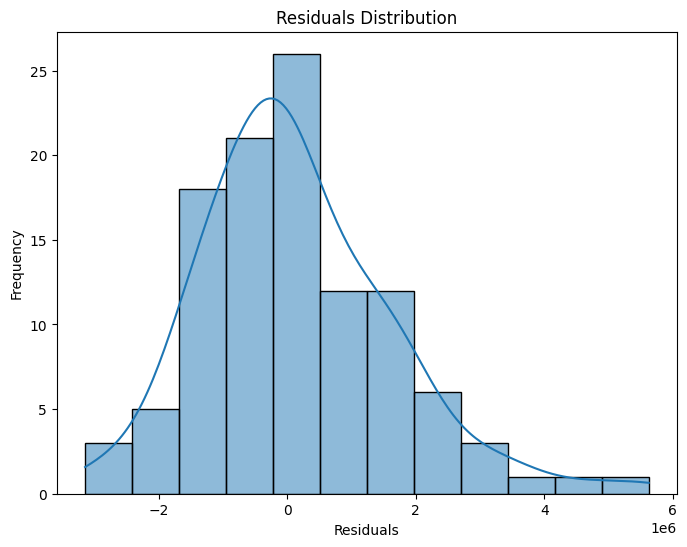

In [35]:
#Plot distribution of residuals
residuals=y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

Outlier Detection

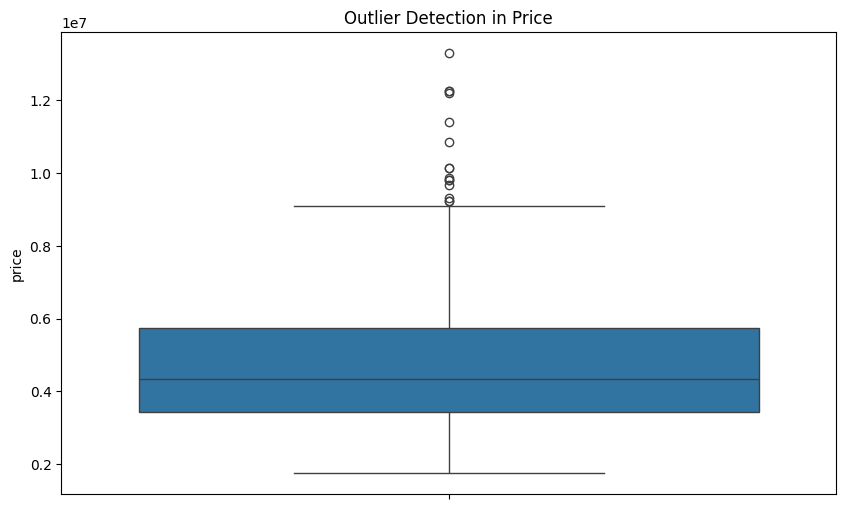

In [36]:
#Plot to detect outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(df['price'])
plt.title('Outlier Detection in Price')
plt.show()

Interaction Terms

In [37]:
# Create interaction terms between features (optional, depending on our dataset)
interaction = PolynomialFeatures (degree=2, interaction_only=True, include_bias=False)
X_train_interaction = interaction.fit_transform(X_train)
X_test_interaction = interaction.transform(X_test)

#Train Linear regression on interaction terms
model_interaction = LinearRegression()
model_interaction.fit(X_train_interaction, y_train)

#Predict and evaluate
y_pred_interaction = model_interaction.predict(X_test_interaction)
interaction_rmse = np.sqrt(mean_squared_error(y_test, y_pred_interaction))
print("Interaction Model RMSE:", interaction_rmse)

Interaction Model RMSE: 1491230.920108234


Save and Load Model

In [39]:
import joblib

#Save the trained model
joblib.dump(model, 'house_price_model.pk1')

#Load the model when needed
loaded_model=joblib.load('house_price_model.pk1')

Pairplot

In [40]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [ ]:
#Strip whitespace from column names
df.columns = df.columns.str.strip()

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


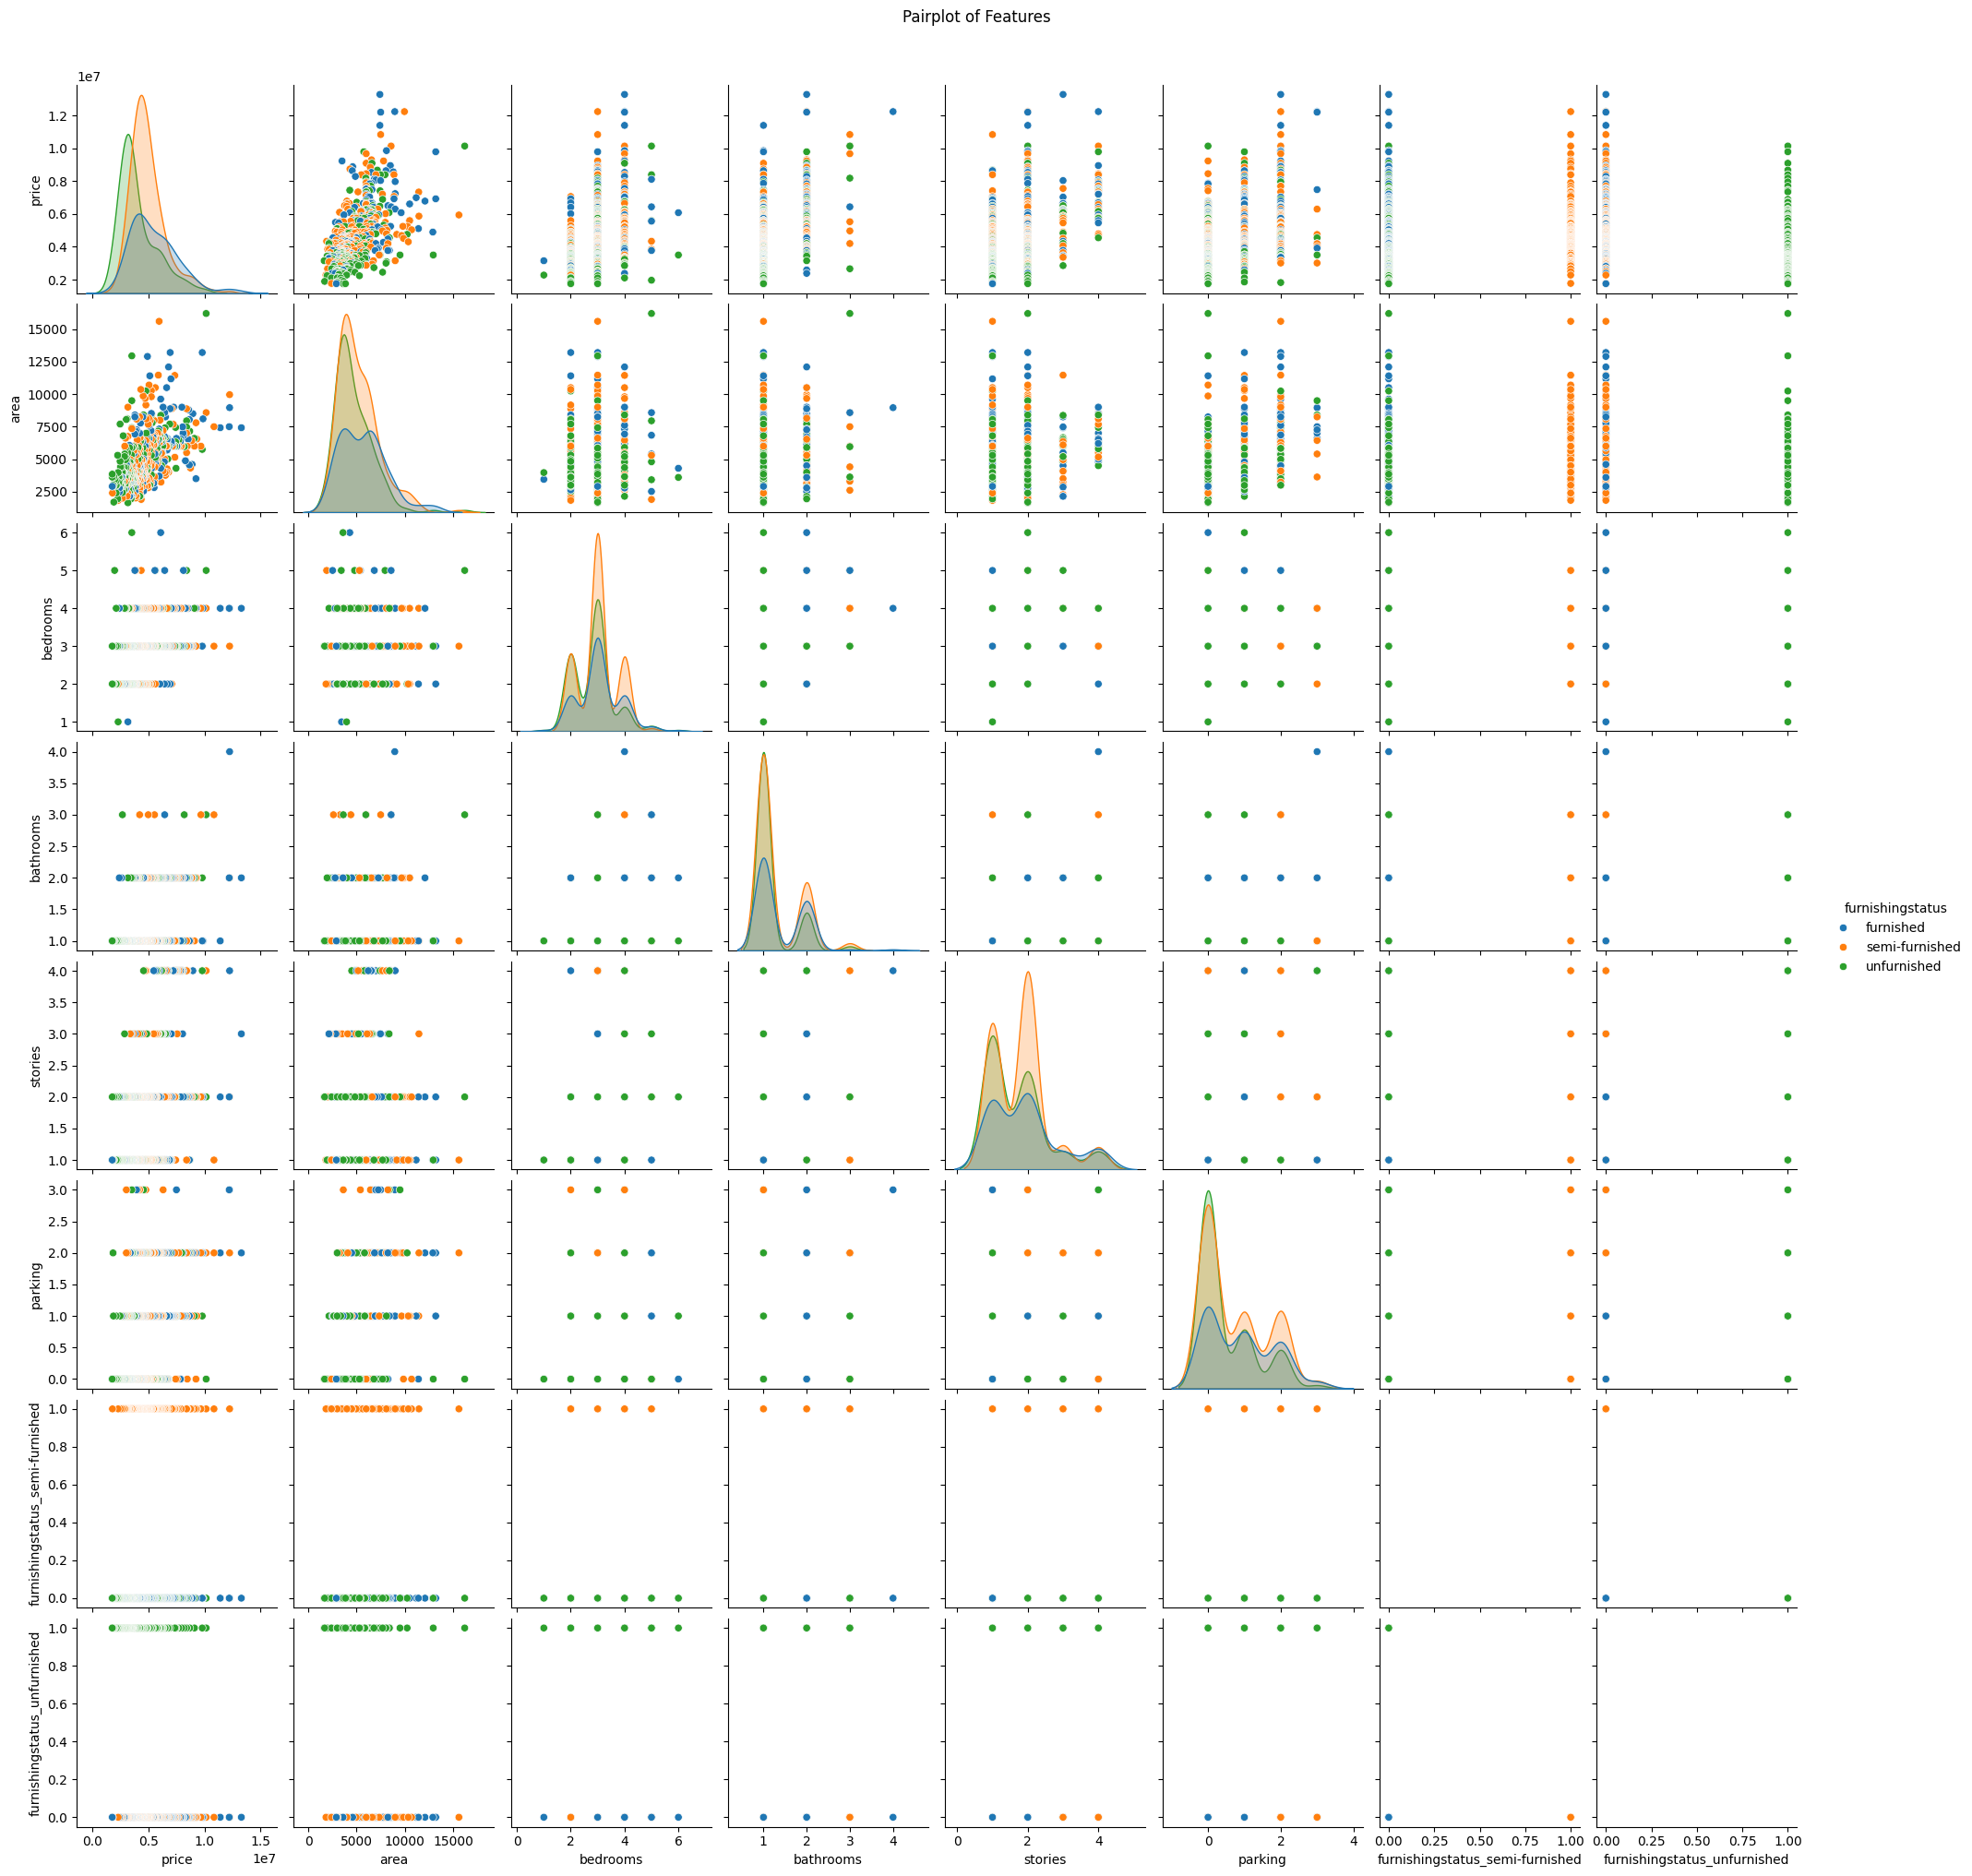

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

#Verify column names
print(df.columns)

# Recreate the 'furnishingstatus' column from the one-hot encoded columns
def get_furnishing_status(row):
    if row['furnishingstatus_unfurnished'] == 1:
        return 'unfurnished'
    elif row['furnishingstatus_semi-furnished'] == 1:
        return 'semi-furnished'
    else:
        return 'furnished'

df['furnishingstatus'] = df.apply(get_furnishing_status, axis=1)

#If everything Looks good, create the pairplot
sns.pairplot(df, diag_kind='kde', hue='furnishingstatus')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

Correaltion Heatmap

In [47]:
print(df.dtypes)

price                               int64
area                                int64
bedrooms                            int64
bathrooms                           int64
stories                             int64
parking                             int64
furnishingstatus_semi-furnished      bool
furnishingstatus_unfurnished         bool
furnishingstatus                   object
dtype: object


In [48]:
#Convert categorical variables to numeric using one-hot encoding
df_encoded=pd.get_dummies(df, drop_first=True)

In [49]:
from sklearn.preprocessing import LabelEncoder

# Example: Encoding a single column
label_encoder=LabelEncoder()
df ['furnishingstatus']=label_encoder.fit_transform(df['furnishingstatus'])

In [50]:
#Calculate the correlation matrix for the encoded data
correlation_matrix=df_encoded.corr()

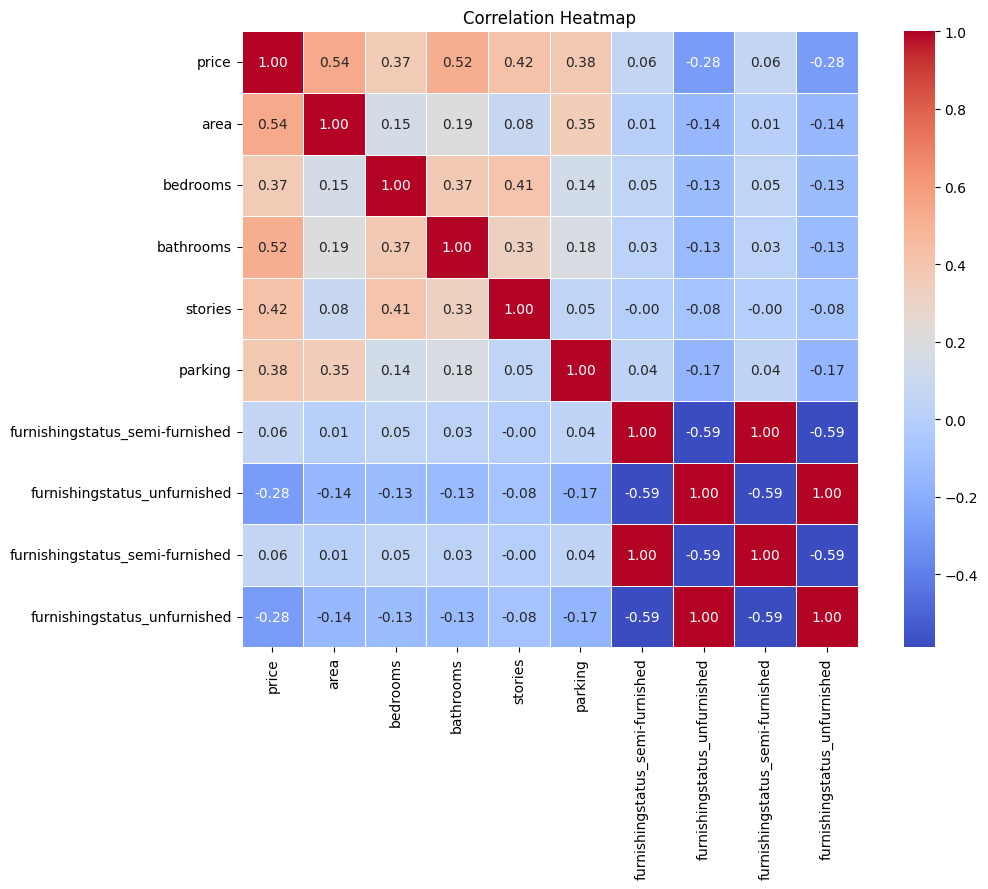

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

#Set up the matplotlib figure
plt.figure(figsize=(12, 8))

#Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

Bar Graphs

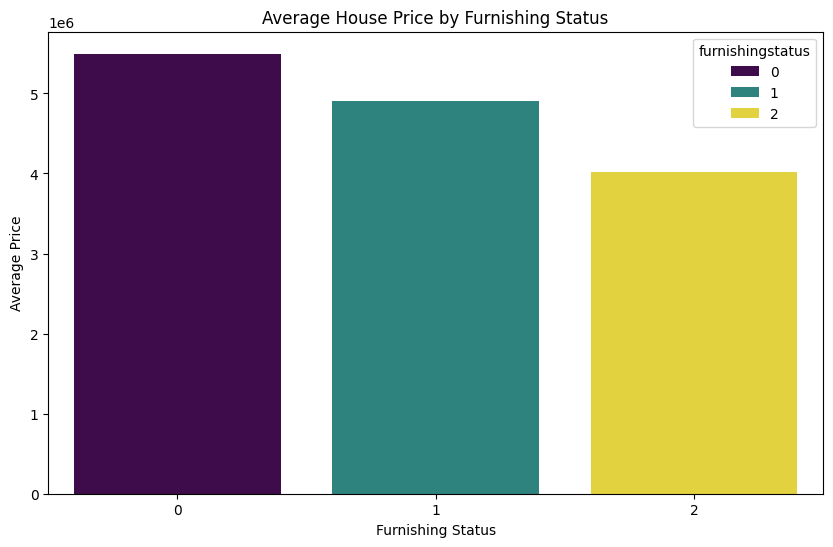

In [54]:
#Average price by furnishing status
avg_price_furnishing=df.groupby('furnishingstatus')['price'].mean().sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_furnishing.index, y=avg_price_furnishing.values, hue=avg_price_furnishing.index, palette='viridis')
plt.title('Average House Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()

Piechart for Categorial Distribution

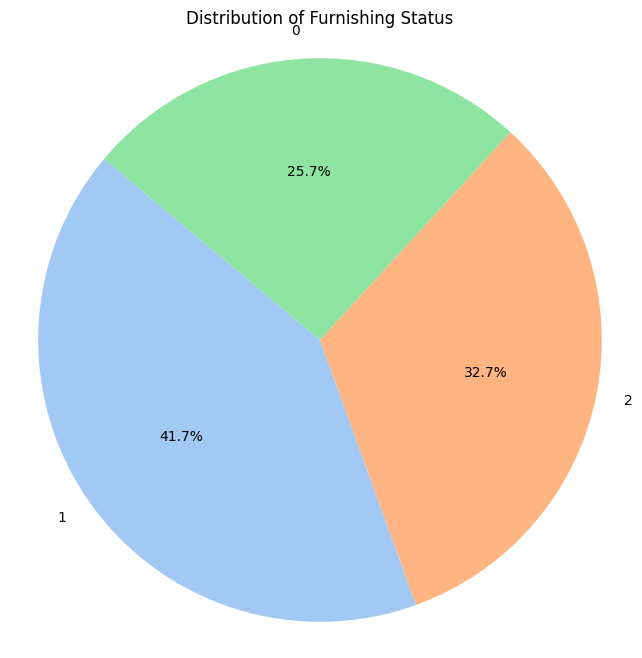

In [55]:
#Pie chart for furnishing status distribution
furnishing_counts=df['furnishingstatus'].value_counts()
plt.figure(figsize=(8, 8))

plt.pie(furnishing_counts, labels=furnishing_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Distribution of Furnishing Status')
plt.axis('equal') #Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

Box Plot for price distribution

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


/tmp/ipython-input-59-1263108322.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='Set1')


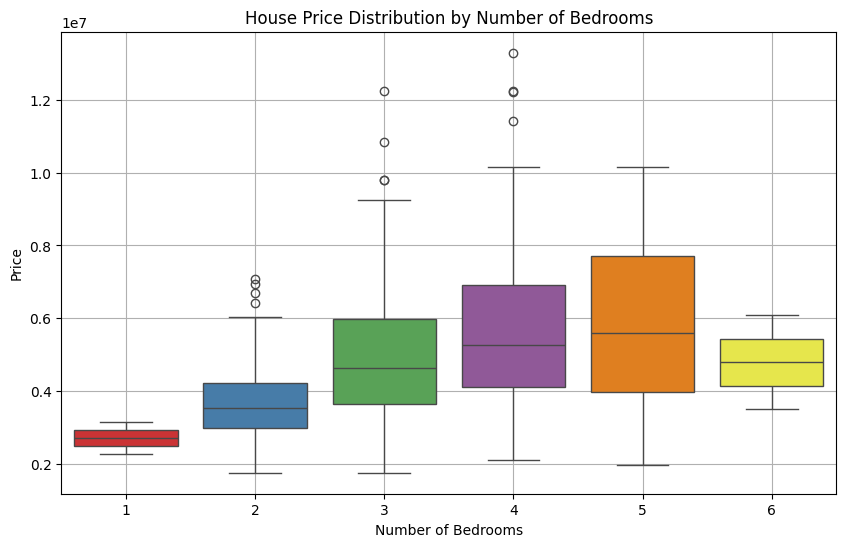

In [59]:
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

#Load dataset
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Housing[1].csv') # Replace with our actual file path

#Check if bedrooms' and 'price' columns exist
print(df.head())

#Box plot for house prices based on the number of bedrooms
plt.figure(figsize=(10, 6))
sns.boxplot(x='bedrooms', y='price', data=df, palette='Set1')
plt.title('House Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Swarm Plot for Detailed Distribution

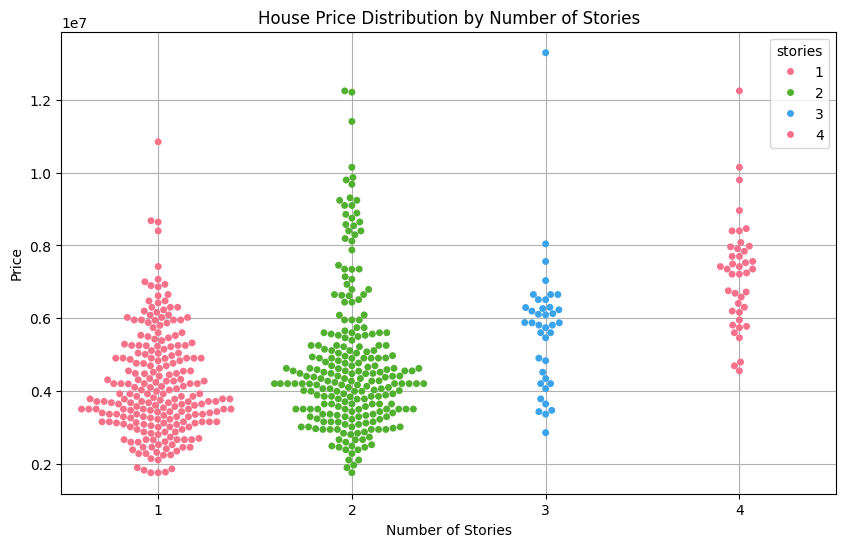

In [61]:
#Swarm plot for house prices based on number of stories
plt.figure(figsize=(10, 6))
sns.swarmplot(x='stories', y='price', data=df, hue='stories', palette='husl')
plt.title('House Price Distribution by Number of Stories')
plt.xlabel('Number of Stories')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Facet Grid For multiple plots

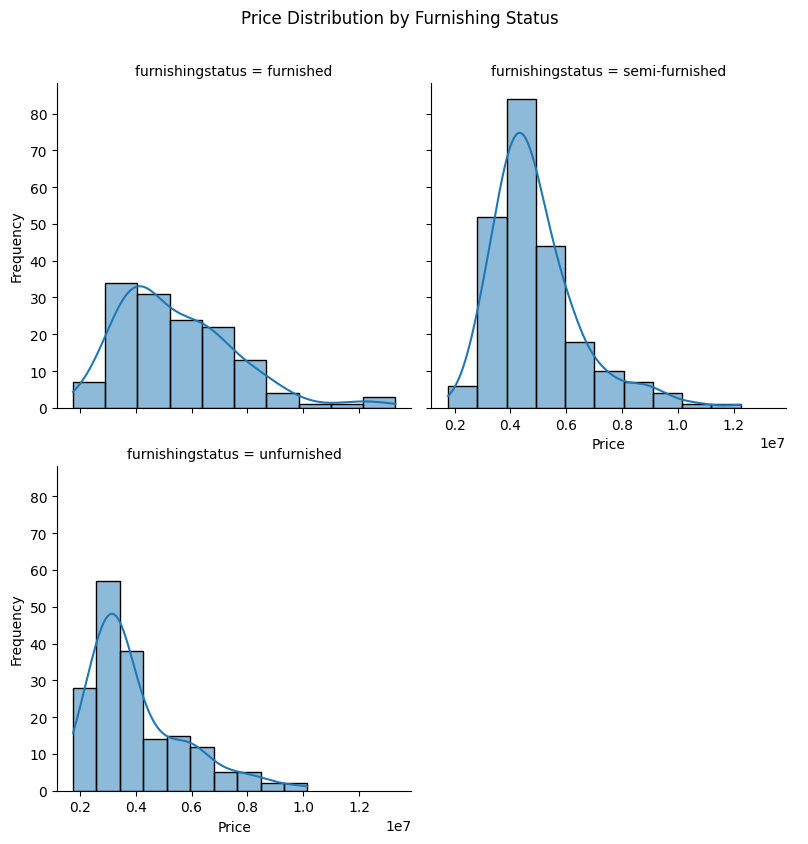

In [62]:
g=sns.FacetGrid(df, col='furnishingstatus', col_wrap=2, height=4)
g.map(sns.histplot, 'price', kde=True, bins=10)
g.add_legend()
g.set_axis_labels('Price', 'Frequency')
g.fig.suptitle('Price Distribution by Furnishing Status', y=1.05)
plt.show()

Joint Plot for feature relationships

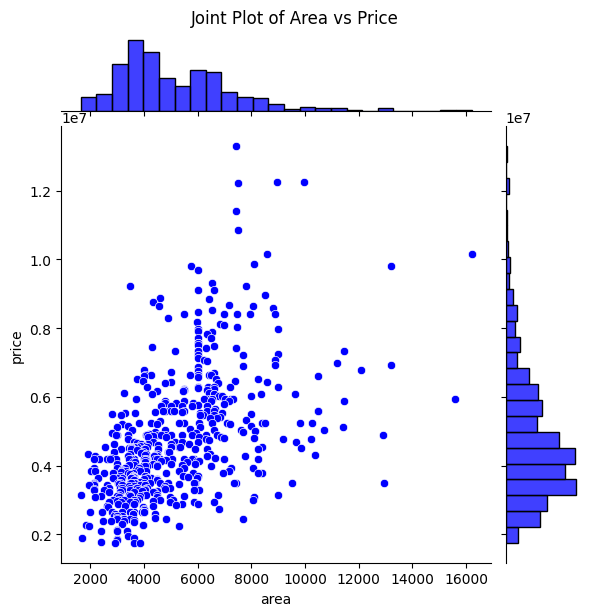

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a joint plot of 'area' vs 'price'
# kind='scatter' displays a scatter plot in the main area
# data=df specifies the DataFrame to use
# marginal_kws customizes the marginal plots (histograms in this case)
sns.jointplot(x='area', y='price', data=df, kind='scatter', color='blue', marginal_kws=dict(bins=25, fill=True))

# Add a title to the joint plot
plt.suptitle('Joint Plot of Area vs Price', y=1.02)

# Display the plot
plt.show()

Radar Chart for Comparative Analysis

Shape of subset for status 0: (0, 13)
Shape of subset for status 2: (0, 13)
Average values for radar chart: [[nan nan nan nan nan nan]
 [nan nan nan nan nan nan]]


ValueError: Axis limits cannot be NaN or Inf

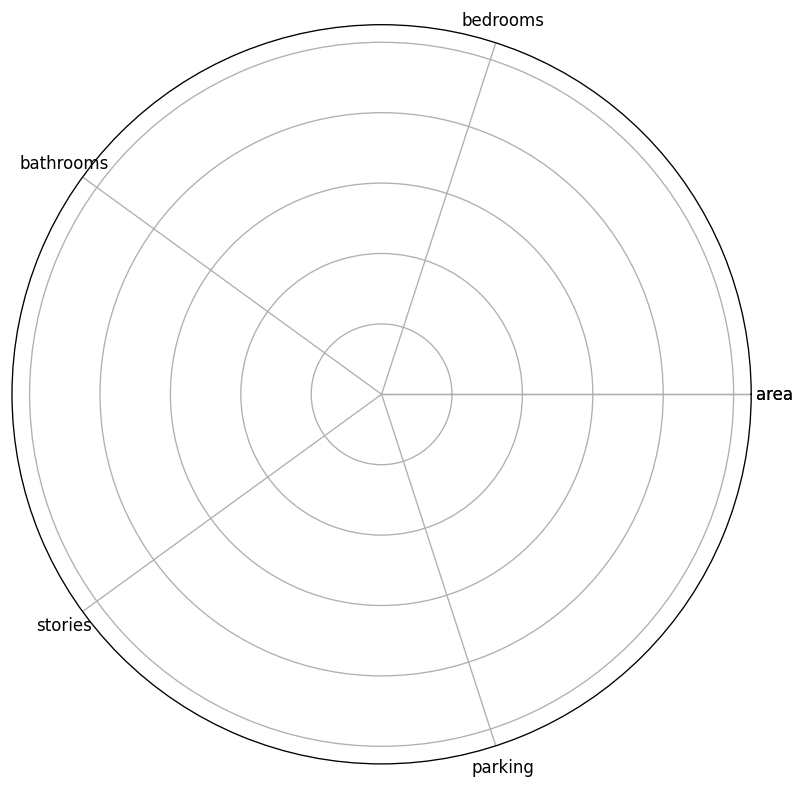

In [75]:
import numpy as np
import matplotlib.pyplot as plt

#Sample data

labels=np.array(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'])
# Use integer values for filtering based on the current state of 'furnishingstatus' column (0: furnished, 1: semi-furnished, 2: unfurnished)
# Get the correct integer labels for 'furnished' and 'unfurnished' from the label encoder
furnished_label = label_encoder.transform(['furnished'])[0]
unfurnished_label = label_encoder.transform(['unfurnished'])[0]

furnishing_statuses = [furnished_label, unfurnished_label]
status_labels = ['Furnished', 'Unfurnished']

#Calculate average values for each furnishing status
# Ensure labels are columns in df and select only numerical columns
avg_values = []
for status in furnishing_statuses:
    subset_df = df[df['furnishingstatus'] == status]
    print(f"Shape of subset for status {status}: {subset_df.shape}") # Check subset shape
    avg_values.append(subset_df[labels].mean().values)

avg_values=np.array(avg_values)

#Radar chart setup
angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()


#Complete the Loop (close the circle)
angles=np.concatenate((angles, [angles[0]]))
avg_values=np.concatenate((avg_values, avg_values[:, [0]]), axis=1)
labels = np.concatenate((labels, [labels[0]])) # Add the first label again to match the angles

#Plotting

plt.figure(figsize=(8, 8), dpi=120)
ax=plt.subplot(111, polar=True)

# Plot each furnishing status
ax.plot(angles, avg_values[0], 'o-', linewidth=2, label=status_labels[0])
ax.fill(angles, avg_values[0], alpha=0.25)

ax.plot(angles, avg_values[1], 'o-', linewidth=2, label=status_labels[1])
ax.fill(angles, avg_values[1], alpha=0.25)


ax.set_yticklabels (()) # Remove the radial ticks
ax.set_xticks (angles) #Set the tick locations to the angles
ax.set_xticklabels (labels) #Set the labels for the ticks

# Print avg_values to check for NaN
print("Average values for radar chart:", avg_values)


# Set the y-axis limits to be slightly larger than the max value for better visualization
ax.set_ylim(0, avg_values.max() * 1.1)


plt.title('Radar Chart Comparing Furnishing Status')
plt.legend(loc='upper right', bbox_to_anchor= (1.1, 1.1))
plt.show()